# Stage 4 — visibility-domain mass recovery

Stage 3-1が保存した複素visibilityを直接fitする。Dirty image pixel間の相関を避け、
各visibilityの複素Gaussian likelihoodでbulge有無のevidenceを比較する。

`UVContext`はuv sampling、primary beam、FINUFFT planをfit workerごとに一度だけ構築する。
Sampling中はmodel cubeだけを更新し、独立したcase/model fitをprocess並列で実行する。


In [1]:
import os

# case/model fitをprocess並列化するため、各process内のnested threadingは止める。
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

from itertools import product
from pathlib import Path
import hashlib
import json
import multiprocessing as mp
import pickle
import time
import tomllib

import dynesty
import matplotlib.pyplot as plt
import numpy as np
from astropy.stats import mad_std
from astropy.table import Table
from cmcrameri import cm
from dynesty import plotting as dyplot

%matplotlib inline

EXAMPLE_DIR = Path.cwd().resolve()
if not (
    EXAMPLE_DIR.name == 'examples'
    or (EXAMPLE_DIR.name == 'forward_mass' and EXAMPLE_DIR.parent.name == 'examples')
):
    raise FileNotFoundError('Run this notebook from examples/forward_mass or examples.')

from glint import lensing
from glint.context import UVContext, build_finufft_plans, build_uv_layout
from glint.cosmology import critical_density, kpc_per_arcsec
from glint.forward import cube_to_visibilities, forward_model_3D_mass_intrinsic, mass_rotation_curve
from glint.inference import run_dynamic_dynesty
from glint.interferometer import ARCSEC2RAD, vis_to_image_finufft_type3
from glint.mass_model import r200_kpc_from_m200


## Configuration and numerical grids

`mock_truth.toml`はStage共通のmock truth、`mock_stage4.toml`はvisibility選択、
FINUFFT精度、free parameters、Dynesty設定だけを持つ。


In [2]:
with (EXAMPLE_DIR / 'mock_truth.toml').open('rb') as handle:
    TRUTH_CONFIG = tomllib.load(handle)
with (EXAMPLE_DIR / 'mock_stage4.toml').open('rb') as handle:
    CONFIG = tomllib.load(handle)

SOURCE_REDSHIFT = float(TRUTH_CONFIG['target']['redshift'])
KPC_PER_ARCSEC = kpc_per_arcsec(SOURCE_REDSHIFT)
RHO_CRITICAL_MSUN_KPC3 = critical_density(SOURCE_REDSHIFT)
mass_cfg = TRUTH_CONFIG['truth']['mass']
source_cfg = TRUTH_CONFIG['truth']['source']
lens_cfg = TRUTH_CONFIG['truth']['lens']
image_grid_cfg = TRUTH_CONFIG['grid']['image']
source_grid_cfg = TRUTH_CONFIG['grid']['source']
spectral_cfg = TRUTH_CONFIG['spectral']
radial_cfg = TRUTH_CONFIG['radial_profile']
uv_cfg = CONFIG['uv_fit']
dynesty_cfg = CONFIG['dynesty']
parallel_cfg = CONFIG['parallel']
HALO_CONCENTRATION_200 = float(mass_cfg['halo_concentration_200'])
DYNESTY_WORKERS_PER_FIT = int(parallel_cfg.get('dynesty_workers_per_fit', 1))
if DYNESTY_WORKERS_PER_FIT != 1:
    raise ValueError('Stage 4 requires dynesty_workers_per_fit = 1; parallelize fits instead')

OUTPUT_DIR = EXAMPLE_DIR / 'output' / 'stage4' / 'results'
CACHE_DIR = OUTPUT_DIR / 'cache'
FIGURE_DIR = OUTPUT_DIR / 'figures'
CASA_WORK_DIR = EXAMPLE_DIR / 'output' / 'stage3' / 'casa_work'
STAGE3_PRODUCT_DIR = EXAMPLE_DIR / 'output' / 'stage3' / 'products'
for directory in (CACHE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

MASS_PARAMETER_NAMES = (
    'log10_m_baryon', 'disk_scale_radius_kpc', 'log10_m200',
    'bulge_to_total', 'bulge_effective_radius_kpc',
)
SOURCE_PARAMETER_NAMES = (
    'source_x_arcsec', 'source_y_arcsec', 'flux_normalization',
    'inclination_deg', 'position_angle_deg', 'surface_brightness_scale_arcsec',
    'velocity_dispersion_center_kms', 'velocity_dispersion_scale_arcsec',
    'systemic_velocity_kms',
)
LENS_PARAMETER_NAMES = (
    'lens_x_arcsec', 'lens_y_arcsec', 'einstein_radius_arcsec',
    'lens_axis_ratio', 'lens_position_angle_deg', 'log10_external_shear',
    'external_shear_position_angle_deg', 'external_convergence',
)
ALL_PARAMETER_NAMES = MASS_PARAMETER_NAMES + SOURCE_PARAMETER_NAMES + LENS_PARAMETER_NAMES
MODEL_FREE_NAMES = {
    'bulge': tuple(CONFIG['fit']['free_parameters_bulge']),
    'no_bulge': tuple(CONFIG['fit']['free_parameters_no_bulge']),
}
BOUNDS = CONFIG['fit']['bounds']
unknown = set().union(*MODEL_FREE_NAMES.values()) - set(ALL_PARAMETER_NAMES)
missing_bounds = set().union(*MODEL_FREE_NAMES.values()) - set(BOUNDS)
if unknown:
    raise ValueError(f'Unsupported fit parameters: {sorted(unknown)}')
if missing_bounds:
    raise ValueError(f'Missing bounds: {sorted(missing_bounds)}')

XX_SOURCE_ARCSEC, YY_SOURCE_ARCSEC = lensing.make_grid_arcsec(
    source_grid_cfg['grid_size'], source_grid_cfg['grid_size'],
    source_grid_cfg['pixel_size_arcsec'],
    source_grid_cfg['x_center_arcsec'], source_grid_cfg['y_center_arcsec'],
)
XX_IMAGE_ARCSEC, YY_IMAGE_ARCSEC = lensing.make_grid_arcsec(
    image_grid_cfg['grid_size'], image_grid_cfg['grid_size'],
    image_grid_cfg['pixel_size_arcsec'],
    image_grid_cfg['x_center_arcsec'], image_grid_cfg['y_center_arcsec'],
)
RADIUS_MAX_KPC = float(radial_cfg['radius_max_kpc'])
RADIAL_STEP_ARCSEC = float(radial_cfg['radial_step_arcsec'])
RADIAL_INTERVALS = int(np.ceil((RADIUS_MAX_KPC / KPC_PER_ARCSEC) / RADIAL_STEP_ARCSEC))
RADIUS_ARCSEC = np.arange(RADIAL_INTERVALS + 1) * RADIAL_STEP_ARCSEC
RADIUS_MAX_ARCSEC = RADIUS_ARCSEC[-1]
RADIUS_KPC = RADIUS_ARCSEC * KPC_PER_ARCSEC
VELOCITY_CHANNELS_KMS = np.arange(
    spectral_cfg['velocity_min_kms'],
    spectral_cfg['velocity_max_kms'] + 0.5 * spectral_cfg['channel_width_kms'],
    spectral_cfg['channel_width_kms'],
)

print(f'image cube: {VELOCITY_CHANNELS_KMS.size} x '
      f'{image_grid_cfg["grid_size"]} x {image_grid_cfg["grid_size"]}')
print(f'parallel: up to {parallel_cfg["max_workers"]} case/model fits; '
      f'{DYNESTY_WORKERS_PER_FIT} Dynesty worker per fit')


image cube: 33 x 200 x 200
parallel: up to 16 case/model fits; 1 Dynesty worker per fit


## Cases and free-lens mass forward model

Stage 2/3-2と同じmass、source、lens parameterizationを使う。違うのは観測演算子だけで、
Stage 4ではPSF畳み込みを行わず、primary beam適用後のlensed cubeをuv点へ直接変換する。


In [3]:
def case_name(bulge_to_total, bulge_effective_radius_kpc):
    return f'bt{round(100 * bulge_to_total):02d}_re{round(10 * bulge_effective_radius_kpc):02d}'


def make_cases():
    cases = [{
        'name': case_name(bt, re_kpc),
        'log10_m_baryon': np.log10(mass_cfg['total_baryonic_mass_msun']),
        'bulge_to_total': float(bt),
        'disk_scale_radius_kpc': float(mass_cfg['disk_scale_radius_kpc']),
        'bulge_effective_radius_kpc': float(re_kpc),
        'log10_m200': np.log10(mass_cfg['halo_mass_200_msun']),
    } for bt, re_kpc in product(
        mass_cfg['bulge_to_total_values'],
        mass_cfg['bulge_effective_radii_kpc'],
    )]
    if mass_cfg.get('include_no_bulge_case', False):
        cases.append({
            'name': 'bt00',
            'log10_m_baryon': np.log10(mass_cfg['total_baryonic_mass_msun']),
            'bulge_to_total': 0.0,
            'disk_scale_radius_kpc': float(mass_cfg['disk_scale_radius_kpc']),
            'bulge_effective_radius_kpc': np.nan,
            'log10_m200': np.log10(mass_cfg['halo_mass_200_msun']),
        })
    return tuple(cases)


CASES = make_cases()


def truth_parameters(case):
    return {
        **{name: float(case[name]) for name in MASS_PARAMETER_NAMES},
        **{name: float(source_cfg[name]) for name in SOURCE_PARAMETER_NAMES},
        **{name: float(lens_cfg[name]) for name in LENS_PARAMETER_NAMES},
    }


def physical_keywords(parameters):
    baryonic_mass = 10.0 ** parameters['log10_m_baryon']
    bulge_mass = parameters['bulge_to_total'] * baryonic_mass
    halo_mass = 10.0 ** parameters['log10_m200']
    return {
        'disk_mass_msun': baryonic_mass - bulge_mass,
        'disk_scale_radius_kpc': parameters['disk_scale_radius_kpc'],
        'bulge_mass_msun': bulge_mass,
        'bulge_effective_radius_kpc': parameters['bulge_effective_radius_kpc'],
        'halo_mass_200_msun': halo_mass,
        'halo_radius_200_kpc': r200_kpc_from_m200(
            halo_mass, RHO_CRITICAL_MSUN_KPC3,
        ),
        'halo_concentration_200': HALO_CONCENTRATION_200,
    }


def intrinsic_cube(parameters):
    surface_brightness = parameters['flux_normalization'] * np.exp(
        -RADIUS_ARCSEC / parameters['surface_brightness_scale_arcsec'],
    )
    velocity_dispersion = parameters['velocity_dispersion_center_kms'] * np.exp(
        -RADIUS_ARCSEC / parameters['velocity_dispersion_scale_arcsec'],
    )
    return forward_model_3D_mass_intrinsic(
        xx_arcsec=XX_SOURCE_ARCSEC, yy_arcsec=YY_SOURCE_ARCSEC,
        radius_arcsec=RADIUS_ARCSEC, kpc_per_arcsec=KPC_PER_ARCSEC,
        velocity_channels_kms=VELOCITY_CHANNELS_KMS,
        surface_brightness_profile=surface_brightness,
        velocity_dispersion_profile_kms=velocity_dispersion,
        inclination_deg=parameters['inclination_deg'],
        position_angle_deg=parameters['position_angle_deg'],
        x_center_arcsec=parameters['source_x_arcsec'],
        y_center_arcsec=parameters['source_y_arcsec'],
        systemic_velocity_kms=parameters['systemic_velocity_kms'],
        spectral_resolution_sigma_kms=spectral_cfg['spectral_resolution_sigma_kms'],
        radius_max_arcsec=RADIUS_MAX_ARCSEC,
        **physical_keywords(parameters),
    )


def lens_keywords(parameters):
    return {
        'x0': parameters['lens_x_arcsec'],
        'y0': parameters['lens_y_arcsec'],
        'b': parameters['einstein_radius_arcsec'],
        'q': parameters['lens_axis_ratio'],
        'pa': np.deg2rad(parameters['lens_position_angle_deg']),
        'log_gamma': parameters['log10_external_shear'],
        'pa_gamma': np.deg2rad(parameters['external_shear_position_angle_deg']),
        'kappa': parameters['external_convergence'],
    }


def lensed_cube(source_cube, parameters):
    alpha_x, alpha_y = lensing.deflection_SIE_plus_ES(
        XX_IMAGE_ARCSEC, YY_IMAGE_ARCSEC, **lens_keywords(parameters),
    )
    image_surface_brightness = lensing.map_source_to_image_cube(
        XX_IMAGE_ARCSEC - alpha_x, YY_IMAGE_ARCSEC - alpha_y,
        source_cube, source_grid_cfg['pixel_size_arcsec'],
        order=int(TRUTH_CONFIG['mock_numerics']['lensing_interpolation_order']),
        x0_src_arcsec=source_grid_cfg['x_center_arcsec'],
        y0_src_arcsec=source_grid_cfg['y_center_arcsec'],
    )
    return image_surface_brightness * image_grid_cfg['pixel_size_arcsec']**2


def rotation_curve(parameters):
    return mass_rotation_curve(radius_kpc=RADIUS_KPC, **physical_keywords(parameters))


Table(
    rows=[(c['name'], c['bulge_to_total'], c['bulge_effective_radius_kpc']) for c in CASES],
    names=('case', 'B/T', 'Re_bulge_kpc'),
)


case,B/T,Re_bulge_kpc
str9,float64,float64
bt10_re03,0.1,0.3
bt10_re06,0.1,0.6
bt25_re03,0.25,0.3
bt25_re06,0.25,0.6
bt50_re03,0.5,0.3
bt50_re06,0.5,0.6
bt00,0.0,nan


## Build and cache the visibility operator

各channelのuv座標、flag、primary beam、FINUFFT planを一度だけ作る。
`max_visibilities_per_channel > 0`は動作確認用の決定論的subsampleで、通常fitは0（全点）を使う。


In [4]:
def load_uv_archive(path):
    with np.load(path, allow_pickle=False) as archive:
        uv = {name: archive[name] for name in archive.files}
    order = np.argsort(uv['v_kms'])
    for name in ('v_kms', 'freqs', 'data', 'sigma', 'weight', 'flag'):
        uv[name] = np.asarray(uv[name])[order]
    uv['uvw_lam'] = np.asarray(uv['uvw_lam'])[:, order]
    uv['pb_fwhm_arcsec'] = np.asarray(uv['pb_fwhm_arcsec'])[order]
    return uv


def limited_flags(flag, maximum):
    result = np.ones_like(flag, dtype=bool)
    for channel in range(flag.shape[0]):
        valid = np.flatnonzero(~flag[channel])
        if maximum > 0 and valid.size > maximum:
            valid = valid[np.linspace(0, valid.size - 1, maximum, dtype=int)]
        result[channel, valid] = False
    return result


def flatten_selected(array, flag, slices):
    output = np.empty(sum(np.count_nonzero(~row) for row in flag), dtype=array.dtype)
    for channel, output_slice in enumerate(slices):
        if output_slice is not None:
            output[output_slice] = array[channel, ~flag[channel]]
    return output


def line_free_weight_scale(data, sigma, flag, edge_channels):
    if edge_channels < 1 or 2 * edge_channels > data.shape[0]:
        raise ValueError('line_free_edge_channels is incompatible with the cube')
    selected_data = np.concatenate((data[:edge_channels], data[-edge_channels:]))
    selected_sigma = np.concatenate((sigma[:edge_channels], sigma[-edge_channels:]))
    selected_flag = np.concatenate((flag[:edge_channels], flag[-edge_channels:]))
    values = selected_data[~selected_flag] / selected_sigma[~selected_flag]
    def mad_sigma(component):
        median = np.median(component)
        return 1.482602218505602 * np.median(np.abs(component - median))
    return 0.5 * (mad_sigma(values.real) + mad_sigma(values.imag))


def build_case_context(case):
    path = CASA_WORK_DIR / case['name'] / 'simulation' / 'uv_data.npz'
    signal_path = CASA_WORK_DIR / case['name'] / 'simulation' / 'signal_uv_data.npz'
    normalization_path = STAGE3_PRODUCT_DIR / case['name'] / 'sn_normalization.json'
    if not path.exists():
        raise FileNotFoundError(f'Run Stage 3-1 first: {path}')
    if not signal_path.exists():
        raise FileNotFoundError(f'Run Stage 3-1 first: {signal_path}')
    if not normalization_path.exists():
        raise FileNotFoundError(f'Run Stage 3-1 first: {normalization_path}')
    normalization = json.loads(normalization_path.read_text())
    uv = load_uv_archive(path)
    signal_uv = load_uv_archive(signal_path)
    if not np.allclose(uv['v_kms'], VELOCITY_CHANNELS_KMS, atol=1.0):
        raise ValueError(f'Channel mismatch for {case["name"]}')
    if (
        signal_uv['data'].shape != uv['data'].shape
        or not np.allclose(signal_uv['uvw_lam'], uv['uvw_lam'])
    ):
        raise ValueError(f'Noisy/signal UV products differ for {case["name"]}')
    flag = limited_flags(
        np.asarray(uv['flag'], dtype=bool),
        int(uv_cfg['max_visibilities_per_channel']),
    )
    k_list, slices, ntotal = build_uv_layout(
        uv['uvw_lam'][0], uv['uvw_lam'][1], flag,
    )
    l_rad = (XX_IMAGE_ARCSEC * ARCSEC2RAD).ravel().astype(np.float32)
    m_rad = (YY_IMAGE_ARCSEC * ARCSEC2RAD).ravel().astype(np.float32)
    plans = build_finufft_plans(
        k_list, l_rad, m_rad, eps=float(uv_cfg['finufft_tolerance']),
    )
    radius = np.hypot(XX_IMAGE_ARCSEC, YY_IMAGE_ARCSEC)
    pb = np.exp(
        -4.0 * np.log(2.0)
        * radius[None]**2 / uv['pb_fwhm_arcsec'][:, None, None]**2
    )
    context = UVContext(
        pb=pb, plans=plans, slices=slices,
        nchan=VELOCITY_CHANNELS_KMS.size, Ntot=ntotal, flag=flag,
    )
    raw_sigma = np.asarray(uv['sigma'], dtype=float)
    if uv_cfg['noise_sigma_source'] == 'scaled_exported':
        noise_scale = line_free_weight_scale(
            np.asarray(uv['data']), raw_sigma, flag,
            int(uv_cfg['line_free_edge_channels']),
        )
        sigma = noise_scale * raw_sigma
    elif uv_cfg['noise_sigma_source'] == 'exported':
        noise_scale = 1.0
        sigma = raw_sigma
    else:
        raise ValueError('noise_sigma_source must be scaled_exported or exported')
    return {
        'path': path,
        'signal_path': signal_path,
        'normalization_path': normalization_path,
        'flux_scale': float(normalization['flux_scale']),
        'input_visibility_rows': int(normalization['input_visibility_rows']),
        'averaged_visibility_rows': int(normalization['averaged_visibility_rows']),
        'max_uv_distance_m': float(normalization['max_uv_distance_m']),
        'uv_context': context,
        'data': flatten_selected(np.asarray(uv['data']), flag, slices),
        'signal_data': flatten_selected(
            np.asarray(signal_uv['data']), flag, slices,
        ),
        'sigma': flatten_selected(sigma, flag, slices),
        'noise_scale': noise_scale,
    }


MOCKS = {case['name']: build_case_context(case) for case in CASES}
for case in CASES:
    mock = MOCKS[case['name']]
    print(f'{case["name"]}: MS rows '
          f'{mock["input_visibility_rows"]:,} -> {mock["averaged_visibility_rows"]:,} '
          f'(max uv movement {mock["max_uv_distance_m"]:g} m); '
          f'{mock["uv_context"].Ntot:,} channel-visibilities, '
          f'{mock["uv_context"].nchan} cached FINUFFT plans, '
          f'sigma={np.median(mock["sigma"]):.5g} Jy')


bt10_re03: MS rows 325,080 -> 6,132 (max uv movement 12 m); 202,356 channel-visibilities, 33 cached FINUFFT plans, sigma=0.018997 Jy
bt10_re06: MS rows 325,080 -> 6,132 (max uv movement 12 m); 202,356 channel-visibilities, 33 cached FINUFFT plans, sigma=0.019014 Jy
bt25_re03: MS rows 325,080 -> 6,132 (max uv movement 12 m); 202,356 channel-visibilities, 33 cached FINUFFT plans, sigma=0.018962 Jy
bt25_re06: MS rows 325,080 -> 6,132 (max uv movement 12 m); 202,356 channel-visibilities, 33 cached FINUFFT plans, sigma=0.019078 Jy
bt50_re03: MS rows 325,080 -> 6,132 (max uv movement 12 m); 202,356 channel-visibilities, 33 cached FINUFFT plans, sigma=0.018949 Jy
bt50_re06: MS rows 325,080 -> 6,132 (max uv movement 12 m); 202,356 channel-visibilities, 33 cached FINUFFT plans, sigma=0.019068 Jy
bt00: MS rows 325,080 -> 6,132 (max uv movement 12 m); 202,356 channel-visibilities, 33 cached FINUFFT plans, sigma=0.01899 Jy


## Visibility likelihood and forward-model validation

CASAの`SIGMA`を実部・虚部それぞれの標準偏差として、
`|data-model|² / sigma²`を用いる。Sampling前にtruth modelのreduced chi-squareと
CASA signal-only visibilityとの一致を確認する。


In [5]:
def complete_parameters(theta, case, model_name):
    parameters = truth_parameters(case)
    if model_name == 'no_bulge':
        parameters['bulge_to_total'] = 0.0
    parameters.update(zip(
        MODEL_FREE_NAMES[model_name], np.asarray(theta, dtype=float), strict=True,
    ))
    return parameters


def prior_transform(unit_cube, model_name):
    names = MODEL_FREE_NAMES[model_name]
    lower = np.array([BOUNDS[name]['lower'] for name in names])
    upper = np.array([BOUNDS[name]['upper'] for name in names])
    return lower + np.asarray(unit_cube) * (upper - lower)


def model_visibilities(parameters, case_name):
    image_cube = (
        MOCKS[case_name]['flux_scale']
        * lensed_cube(intrinsic_cube(parameters), parameters)
    )
    return cube_to_visibilities(
        image_cube, MOCKS[case_name]['uv_context'],
    )


def make_loglikelihood(case, model_name):
    mock = MOCKS[case['name']]
    data = mock['data']
    sigma = mock['sigma']
    log_normalization = np.sum(np.log(2.0 * np.pi * sigma**2))

    def loglikelihood(theta):
        model = model_visibilities(
            complete_parameters(theta, case, model_name),
            case['name'],
        )
        chi2 = np.sum(np.abs((data - model) / sigma) ** 2)
        return -0.5 * (chi2 + log_normalization)

    return loglikelihood


reference_case = CASES[0]
truth = truth_parameters(reference_case)
serial_vis = model_visibilities(truth, reference_case['name'])
mock = MOCKS[reference_case['name']]
truth_chi2 = np.sum(np.abs((mock['data'] - serial_vis) / mock['sigma'])**2)
truth_reduced_chi2 = truth_chi2 / (2 * mock['data'].size)
noise_chi2 = np.sum(
    np.abs((mock['data'] - mock['signal_data']) / mock['sigma'])**2
)
noise_reduced_chi2 = noise_chi2 / (2 * mock['data'].size)
signal_model_rms = np.sqrt(np.mean(np.abs(mock['signal_data'] - serial_vis)**2))
signal_rms = np.sqrt(np.mean(np.abs(mock['signal_data'])**2))
print(f'truth visibility reduced chi-square = {truth_reduced_chi2:.3f}')
print(f'noise-only reduced chi-square = {noise_reduced_chi2:.3f}')
print(f'CASA-signal / FINUFFT-model relative RMS = {signal_model_rms/signal_rms:.3e}')
benchmark_rng = np.random.default_rng(1234)
benchmark_points = [
    prior_transform(
        benchmark_rng.random(len(MODEL_FREE_NAMES['bulge'])), 'bulge',
    ) for _ in range(5)
]
benchmark_loglike = make_loglikelihood(reference_case, 'bulge')
start = time.perf_counter()
for point in benchmark_points:
    benchmark_loglike(point)
seconds_per_loglike = (time.perf_counter() - start) / len(benchmark_points)
print(f'{seconds_per_loglike:.3f} s per visibility likelihood per fit worker')


truth visibility reduced chi-square = 1.005
noise-only reduced chi-square = 1.005
CASA-signal / FINUFFT-model relative RMS = 1.076e-01
0.109 s per visibility likelihood per fit worker


## Dynamic nested sampling

1 taskは1 physical case × 1 model。各processが専用のFINUFFT planを構築してDynestyを実行する。
同じplanをprocess間で共有せず、cache missのtaskだけを並列実行する。


In [6]:
def weighted_quantile(values, quantiles, weights):
    order = np.argsort(values)
    sorted_values = np.asarray(values)[order]
    cumulative = np.cumsum(np.asarray(weights)[order])
    cumulative /= cumulative[-1]
    return np.interp(quantiles, cumulative, sorted_values)


def run_nested_fit(case, model_name, task_seed, show_progress=False):
    names = MODEL_FREE_NAMES[model_name]
    start = time.perf_counter()
    loglikelihood = make_loglikelihood(case, model_name)
    results = run_dynamic_dynesty(
        loglikelihood, lambda u: prior_transform(u, model_name), len(names),
        nlive_init=dynesty_cfg['nlive_init'],
        nlive_batch=dynesty_cfg['nlive_batch'],
        dlogz_init=dynesty_cfg['dlogz_init'],
        pfrac=dynesty_cfg['pfrac'],
        evidence_threshold=dynesty_cfg['evidence_threshold'],
        target_n_effective=dynesty_cfg['target_n_effective'],
        max_batches=dynesty_cfg['max_batches'],
        bound=dynesty_cfg['bound'], sample=dynesty_cfg['sample'],
        rstate=np.random.default_rng(np.random.SeedSequence([
            dynesty_cfg['random_seed'], task_seed,
        ])),
        print_progress=show_progress,
    )
    elapsed = time.perf_counter() - start
    weights = np.exp(results.logwt - results.logz[-1])
    posterior = {
        name: weighted_quantile(
            results.samples[:, column], [0.16, 0.50, 0.84], weights,
        )
        for column, name in enumerate(names)
    }
    best_index = int(np.argmax(results.logl))
    return {
        'results': results,
        'weights': weights,
        'posterior': posterior,
        'best_parameters': complete_parameters(
            results.samples[best_index], case, model_name,
        ),
        'logz': float(results.logz[-1]),
        'logzerr': float(results.logzerr[-1]),
        'max_logl': float(results.logl[best_index]),
        'ncall': int(np.sum(results.ncall)),
        'elapsed_seconds': elapsed,
    }


def run_nested_task(task):
    case, model_name, task_seed, show_progress = task
    # fork元のplanを使わず、worker process内で専用contextを作る。
    MOCKS[case['name']] = build_case_context(case)
    return case['name'], model_name, run_nested_fit(
        case, model_name, task_seed, show_progress,
    )


def stable_task_seed(case_name, model_name):
    digest = hashlib.sha256(f'{case_name}:{model_name}'.encode()).digest()
    return int.from_bytes(digest[:4], byteorder='little')


def file_hash(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def sampling_metadata(case, model_name):
    return {
        'cache_version': 1,
        'truth_config': TRUTH_CONFIG,
        'stage_config': {key: value for key, value in CONFIG.items() if key != 'parallel'},
        'case': case,
        'model_name': model_name,
        'uv_data_sha256': file_hash(MOCKS[case['name']]['path']),
        'signal_uv_data_sha256': file_hash(MOCKS[case['name']]['signal_path']),
        'flux_normalization_sha256': file_hash(
            MOCKS[case['name']]['normalization_path']
        ),
    }


CACHE_IGNORED_METADATA_KEYS = {
    'source_hashes', 'function_hashes', 'dependency_hashes',
    'dynesty_version', 'numpy_version',
}

def cache_relevant_metadata(metadata):
    return {key: value for key, value in metadata.items()
            if key not in CACHE_IGNORED_METADATA_KEYS}

def sampling_fingerprint(metadata):
    serialized = json.dumps(
        cache_relevant_metadata(metadata), sort_keys=True,
        default=lambda value: value.item() if isinstance(value, np.generic) else str(value),
    )
    return hashlib.sha256(serialized.encode()).hexdigest()


def cache_path(case_name, model_name):
    return CACHE_DIR / f'{case_name}__{model_name}.pkl'


def load_cached_result(case_name, model_name, metadata):
    path = cache_path(case_name, model_name)
    if not path.exists():
        return None
    try:
        with path.open('rb') as handle:
            payload = pickle.load(handle)
    except (OSError, EOFError, pickle.UnpicklingError):
        print(f'{case_name:10s} {model_name:9s}: unreadable cache ignored')
        return None
    cached_metadata = payload.get('metadata')
    if (cached_metadata is not None
            and sampling_fingerprint(cached_metadata) == sampling_fingerprint(metadata)):
        return payload['result']
    print(f'{case_name:10s} {model_name:9s}: stale cache ignored')
    return None


def save_cached_result(case_name, model_name, metadata, result):
    path = cache_path(case_name, model_name)
    temporary = path.with_suffix('.tmp')
    payload = {
        'fingerprint': sampling_fingerprint(metadata),
        'metadata': metadata,
        'result': result,
    }
    with temporary.open('wb') as handle:
        pickle.dump(payload, handle, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(temporary, path)


RESULTS = {}
BENCHMARK_ONLY = os.getenv('STAGE4_BENCHMARK_ONLY', '0') == '1'
if not BENCHMARK_ONLY:
    max_cases = int(os.getenv('STAGE4_MAX_CASES', str(len(CASES))))
    run_models = tuple(
        name.strip()
        for name in os.getenv('STAGE4_MODELS', 'no_bulge,bulge').split(',')
    )
    if not set(run_models) <= set(MODEL_FREE_NAMES):
        raise ValueError(f'Unknown STAGE4_MODELS value: {run_models}')
    run_cases = CASES[:max_cases]
    force_refit = os.getenv('STAGE4_FORCE_REFIT', '0') == '1'
    tasks = []
    metadata_by_key = {}
    for case, model_name in product(run_cases, run_models):
        key = (case['name'], model_name)
        metadata = sampling_metadata(case, model_name)
        metadata_by_key[key] = metadata
        cached = None if force_refit else load_cached_result(*key, metadata)
        if cached is None:
            # 先頭のcache-miss fitだけDynesty標準の進捗を表示する。
            tasks.append((case, model_name, stable_task_seed(*key), len(tasks) == 0))
        else:
            RESULTS.setdefault(case['name'], {})[model_name] = cached
            print(f'{case["name"]:10s} {model_name:9s}: loaded valid cache')

    total_start = time.perf_counter()
    if tasks:
        max_workers = min(int(parallel_cfg['max_workers']), os.cpu_count() or 1, len(tasks))
        print(f'running {len(tasks)} cache-miss fits with {max_workers} processes')
        if max_workers == 1:
            completed_tasks = map(run_nested_task, tasks)
            pool = None
        else:
            context = mp.get_context(parallel_cfg['start_method'])
            pool = context.Pool(processes=max_workers)
            completed_tasks = pool.imap_unordered(run_nested_task, tasks, chunksize=1)
        try:
            for case_name, model_name, result in completed_tasks:
                RESULTS.setdefault(case_name, {})[model_name] = result
                save_cached_result(
                    case_name, model_name,
                    metadata_by_key[(case_name, model_name)], result,
                )
                print(f'{case_name:10s} {model_name:9s}: '
                      f'lnZ={result["logz"]:.2f} +/- {result["logzerr"]:.2f}, '
                      f'calls={result["ncall"]:,}, '
                      f'fit time={result["elapsed_seconds"]/60:.1f} min; cache saved')
        finally:
            if pool is not None:
                pool.close()
                pool.join()
    else:
        print('all requested fits loaded from valid caches; Dynesty sampling skipped')
    print(f'total sampling/cache wall time = {(time.perf_counter()-total_start)/60:.2f} min')
else:
    print('Benchmark-only mode: Dynesty sampling skipped.')


bt10_re03  no_bulge : loaded valid cache
bt10_re03  bulge    : loaded valid cache
bt10_re06  no_bulge : loaded valid cache
bt10_re06  bulge    : loaded valid cache
bt25_re03  no_bulge : loaded valid cache
bt25_re03  bulge    : loaded valid cache
bt25_re06  no_bulge : loaded valid cache
bt25_re06  bulge    : loaded valid cache
bt50_re03  no_bulge : loaded valid cache
bt50_re03  bulge    : loaded valid cache
bt50_re06  no_bulge : loaded valid cache
bt50_re06  bulge    : loaded valid cache
bt00       no_bulge : loaded valid cache
bt00       bulge    : loaded valid cache
all requested fits loaded from valid caches; Dynesty sampling skipped
total sampling/cache wall time = 0.00 min


## Evidence and posterior diagnostics

両modelが揃えばevidence差の表とStage 2同様の$\Delta\ln Z$診断図を表示・PDF保存する。
各resultについてDynesty標準のrun plotとcorner plotもPDF保存する。


case,lnZ no bulge,lnZ bulge,Delta lnZ,Delta lnZ numerical error
str9,float64,float64,float64,float64
bt10_re03,419654.191,419770.732,116.542,0.429
bt10_re06,420050.336,420082.232,31.897,0.438
bt25_re03,419483.053,419739.944,256.891,0.455
bt25_re06,420684.201,420777.812,93.612,0.435
bt50_re03,419869.003,420232.231,363.228,0.472
bt50_re06,421410.699,421605.699,195.000,0.437
bt00,419226.334,419224.273,-2.060,0.430


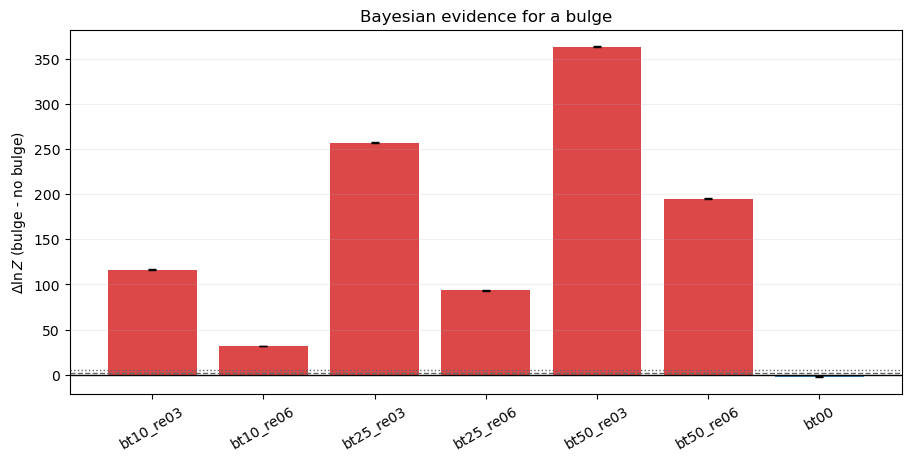

saved evidence diagnostic: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage4/results/figures/evidence_bulge_comparison.pdf
saved Dynesty diagnostics: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage4/results/figures/bt10_re03/no_bulge
saved Dynesty diagnostics: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage4/results/figures/bt10_re03/bulge
saved Dynesty diagnostics: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage4/results/figures/bt10_re06/no_bulge
saved Dynesty diagnostics: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage4/results/figures/bt10_re06/bulge
saved Dynesty diagnostics: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage4/results/figures/bt25_re03/no_bulge
saved Dynesty diagnostics: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage4/results/figures/bt25_re03/bulge
saved Dynesty diagnostics: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/

In [7]:
FULL_RESULTS = (
    len(RESULTS) == len(CASES)
    and all(set(result) == {'no_bulge', 'bulge'} for result in RESULTS.values())
)
if FULL_RESULTS:
    rows = []
    for case in CASES:
        no_bulge = RESULTS[case['name']]['no_bulge']
        bulge = RESULTS[case['name']]['bulge']
        rows.append((
            case['name'], no_bulge['logz'], bulge['logz'],
            bulge['logz'] - no_bulge['logz'],
            np.hypot(no_bulge['logzerr'], bulge['logzerr']),
        ))
    EVIDENCE_TABLE = Table(
        rows=rows,
        names=(
            'case', 'lnZ no bulge', 'lnZ bulge', 'Delta lnZ',
            'Delta lnZ numerical error',
        ),
    )
    for name in EVIDENCE_TABLE.colnames[1:]:
        EVIDENCE_TABLE[name].format = '.3f'
    display(EVIDENCE_TABLE)

    fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
    delta = np.asarray(EVIDENCE_TABLE['Delta lnZ'])
    error = np.asarray(EVIDENCE_TABLE['Delta lnZ numerical error'])
    colors = [
        'tab:blue' if value < 2.5 else
        'tab:orange' if value < 5.0 else 'tab:red'
        for value in delta
    ]
    positions = np.arange(len(CASES))
    ax.bar(positions, delta, yerr=error, color=colors, alpha=0.85, capsize=3)
    ax.axhline(0, color='black', lw=1)
    ax.axhline(2.5, color='0.4', lw=1, ls='--')
    ax.axhline(5.0, color='0.4', lw=1, ls=':')
    ax.set_xticks(positions, [case['name'] for case in CASES], rotation=30)
    ax.set_ylabel(r'$\Delta\ln Z$ (bulge - no bulge)')
    ax.set_title('Bayesian evidence for a bulge')
    ax.grid(axis='y', alpha=0.2)
    evidence_path = FIGURE_DIR / 'evidence_bulge_comparison.pdf'
    fig.savefig(evidence_path, bbox_inches='tight')
    plt.show()
    print(f'saved evidence diagnostic: {evidence_path}')

for case_name, model_results in RESULTS.items():
    for model_name, result in model_results.items():
        directory = FIGURE_DIR / case_name / model_name
        directory.mkdir(parents=True, exist_ok=True)
        # Complex-Gaussian normalization makes absolute ln Z large and
        # positive; logplot=False exponentiates it and overflows.
        fig, _ = dyplot.runplot(result['results'], logplot=True)
        fig.savefig(directory / 'dynesty_runplot.pdf', bbox_inches='tight')
        plt.close(fig)
        labels = MODEL_FREE_NAMES[model_name]
        fig, _ = dyplot.cornerplot(
            result['results'], labels=labels, show_titles=True,
        )
        fig.savefig(directory / 'dynesty_cornerplot.pdf', bbox_inches='tight')
        plt.close(fig)
        print(f'saved Dynesty diagnostics: {directory}')


## Best-fit channel diagnostics

Maximum-likelihood visibility modelを観測と同じuv sampling・natural weightでdirty image化する。
各PDFの4列は、noisy mock observation、best-fit model、dirty residual、intrinsic sourceである。
最初の3列は共通の`cm.roma_r`とcolor limitsを使い、contourだけをdirty RMSで標準化する。
Dirty imageは表示用であり、fitと$\chi^2$評価そのものは独立な複素visibility上で行う。


In [8]:
def dirty_cube(flat_visibilities, case_name):
    """Selected visibility vectorをfitと同じuv点・weightでdirty image化する。"""
    mock = MOCKS[case_name]
    uv = load_uv_archive(mock['path'])
    context = mock['uv_context']
    cube = np.empty((context.nchan, *XX_IMAGE_ARCSEC.shape), dtype=float)
    beam = np.empty_like(cube)
    for channel, output_slice in enumerate(context.slices):
        selected = ~context.flag[channel]
        weight = 1.0 / mock['sigma'][output_slice]**2
        cube[channel], beam[channel] = vis_to_image_finufft_type3(
            uv['uvw_lam'][0, channel, selected],
            uv['uvw_lam'][1, channel, selected],
            flat_visibilities[output_slice], weight,
            XX_IMAGE_ARCSEC, YY_IMAGE_ARCSEC,
            eps=float(uv_cfg['finufft_tolerance']),
        )
    return cube, beam


def save_channel_diagnostics():
    rows = []
    image_extent = [
        XX_IMAGE_ARCSEC.min(), XX_IMAGE_ARCSEC.max(),
        YY_IMAGE_ARCSEC.min(), YY_IMAGE_ARCSEC.max(),
    ]
    source_extent = [
        XX_SOURCE_ARCSEC.min(), XX_SOURCE_ARCSEC.max(),
        YY_SOURCE_ARCSEC.min(), YY_SOURCE_ARCSEC.max(),
    ]
    for case in CASES:
        case_name = case['name']
        mock = MOCKS[case_name]
        observed_dirty, _ = dirty_cube(mock['data'], case_name)
        noise_dirty, _ = dirty_cube(mock['data'] - mock['signal_data'], case_name)
        noise_rms = np.asarray([
            mad_std(channel, ignore_nan=True) for channel in noise_dirty
        ])
        fallback_rms = np.std(noise_dirty, axis=(1, 2))
        noise_rms = np.where(
            np.isfinite(noise_rms) & (noise_rms > 0), noise_rms, fallback_rms,
        )

        for model_name in ('no_bulge', 'bulge'):
            result = RESULTS[case_name][model_name]
            best = result['best_parameters']
            best_visibilities = model_visibilities(best, case_name)
            model_dirty, _ = dirty_cube(best_visibilities, case_name)
            residual_dirty = observed_dirty - model_dirty
            residual_sigma = residual_dirty / noise_rms[:, None, None]
            source = intrinsic_cube(best)

            visibility_chi2 = float(np.sum(
                np.abs((mock['data'] - best_visibilities) / mock['sigma'])**2
            ))
            dof = 2 * mock['data'].size - len(MODEL_FREE_NAMES[model_name])
            reduced_chi2 = visibility_chi2 / dof
            rows.append((case_name, model_name, visibility_chi2, dof, reduced_chi2))

            directory = FIGURE_DIR / case_name / model_name
            directory.mkdir(parents=True, exist_ok=True)
            n_channels = len(VELOCITY_CHANNELS_KMS)
            fig, axes = plt.subplots(
                n_channels, 4, figsize=(8.5, 1.65 * n_channels), squeeze=False,
            )
            fig.subplots_adjust(wspace=0.02, hspace=0.02, top=0.975)
            image_vmin = -2.0 * float(np.median(noise_rms))
            image_vmax = 0.9 * max(
                float(np.nanmax(observed_dirty)), float(np.nanmax(model_dirty)),
            )
            source_vmax = float(np.nanmax(source))

            for channel, velocity_kms in enumerate(VELOCITY_CHANNELS_KMS):
                panels = (
                    (observed_dirty[channel], cm.roma_r, image_vmin, image_vmax, image_extent),
                    (model_dirty[channel], cm.roma_r, image_vmin, image_vmax, image_extent),
                    (residual_dirty[channel], cm.roma_r, image_vmin, image_vmax, image_extent),
                    (source[channel], cm.roma_r, 0.0, source_vmax, source_extent),
                )
                for column, (panel, cmap, vmin, vmax, extent) in enumerate(panels):
                    axes[channel, column].imshow(
                        panel, origin='lower', extent=extent,
                        cmap=cmap, vmin=vmin, vmax=vmax,
                    )
                    axes[channel, column].set_xticks([])
                    axes[channel, column].set_yticks([])
                observed_snr = observed_dirty[channel] / noise_rms[channel]
                model_snr = model_dirty[channel] / noise_rms[channel]
                for column, snr_map in ((0, observed_snr), (1, model_snr)):
                    peak = float(np.nanmax(snr_map))
                    if peak >= 8.0:
                        levels = [level for level in (8.0, 16.0, 32.0) if level <= peak]
                        axes[channel, column].contour(
                            snr_map, levels=levels, colors='black',
                            linewidths=0.25, alpha=0.55,
                            origin='lower', extent=image_extent,
                        )
                residual_levels = [
                    level for level in (-5.0, -4.0, -3.0, 3.0, 4.0, 5.0)
                    if np.nanmin(residual_sigma[channel]) <= level <= np.nanmax(residual_sigma[channel])
                ]
                if residual_levels:
                    axes[channel, 2].contour(
                        residual_sigma[channel], levels=residual_levels,
                        colors='black', linewidths=0.25, alpha=0.55,
                        origin='lower', extent=image_extent,
                    )
                axes[channel, 0].text(
                    0.03, 0.93,
                    f'{velocity_kms:+.0f} km/s; Peak S/N={np.nanmax(observed_snr):.1f}',
                    transform=axes[channel, 0].transAxes,
                    color='white', fontsize=7, va='top',
                )

            titles = (
                'Truth / observed dirty', 'Best-fit model dirty',
                'Residual dirty', 'Best-fit intrinsic source',
            )
            for axis_object, title in zip(axes[0], titles, strict=True):
                axis_object.set_title(title, fontsize=9)
            fig.suptitle(
                f'{case_name} — {model_name}; visibility reduced $\\chi^2$={reduced_chi2:.3f}',
                fontsize=10, y=0.995,
            )
            output_path = directory / 'all_channel_dirty_comparison.pdf'
            fig.savefig(output_path, bbox_inches='tight', pad_inches=0.03)
            plt.close(fig)
            print(f'saved {output_path.relative_to(EXAMPLE_DIR)}')

    diagnostics = Table(
        rows=rows,
        names=('case', 'model', 'visibility_chi2', 'dof', 'reduced_chi2'),
    )
    for name in diagnostics.colnames[2:]:
        diagnostics[name].format = '.5g'
    diagnostics_path = OUTPUT_DIR / 'fit_diagnostics.csv'
    diagnostics.write(diagnostics_path, format='ascii.csv', overwrite=True)
    display(diagnostics)
    print(f'saved {diagnostics_path.relative_to(EXAMPLE_DIR)}')
    return diagnostics


if FULL_RESULTS:
    FIT_DIAGNOSTICS = save_channel_diagnostics()
else:
    print('channel diagnostics skipped: all case/model results are required')


saved output/stage4/results/figures/bt10_re03/no_bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt10_re03/bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt10_re06/no_bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt10_re06/bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt25_re03/no_bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt25_re03/bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt25_re06/no_bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt25_re06/bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt50_re03/no_bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt50_re03/bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt50_re06/no_bulge/all_channel_dirty_comparison.pdf
saved output/stage4/results/figures/bt50_re06/b

case,model,visibility_chi2,dof,reduced_chi2
str9,str8,float64,int64,float64
bt10_re03,no_bulge,4.0693e+05,4.0469e+05,1.0055
bt10_re03,bulge,4.067e+05,4.0469e+05,1.005
bt10_re06,no_bulge,4.0577e+05,4.0469e+05,1.0027
bt10_re06,bulge,4.0571e+05,4.0469e+05,1.0025
bt25_re03,no_bulge,4.0799e+05,4.0469e+05,1.0081
bt25_re03,bulge,4.0748e+05,4.0469e+05,1.0069
bt25_re06,no_bulge,4.0315e+05,4.0469e+05,0.99618
bt25_re06,bulge,4.0296e+05,4.0469e+05,0.99573
bt50_re03,no_bulge,4.075e+05,4.0469e+05,1.0069


saved output/stage4/results/fit_diagnostics.csv


## Rotation curves with posterior uncertainty

Maximum-likelihood sampleをbest-fit線として表示し、joint weighted posteriorを物理的回転曲線へ伝播した
16–84 percentileを帯で示す。総回転曲線のケース比較と、bulge/no-bulge fit別の成分分解を保存する。


In [9]:
ROTATION_COMPONENTS = ('total', 'disk', 'bulge', 'halo')


def posterior_rotation_curve_intervals(case, model_name, max_samples=2000):
    """Joint Dynesty posteriorを各mass componentの回転曲線へ伝播する。"""
    result = RESULTS[case['name']][model_name]
    samples = np.asarray(result['results'].samples)
    weights = np.asarray(result['weights'], dtype=float)
    weights /= weights.sum()
    sample_count = min(max_samples, samples.shape[0])
    rng = np.random.default_rng(stable_task_seed(case['name'], model_name) + 104729)
    indices = rng.choice(
        samples.shape[0], size=sample_count, replace=True, p=weights,
    )
    curves = {
        component: np.empty((sample_count, RADIUS_KPC.size), dtype=float)
        for component in ROTATION_COMPONENTS
    }
    for row, sample_index in enumerate(indices):
        parameters = complete_parameters(samples[sample_index], case, model_name)
        curve = rotation_curve(parameters)
        for component in ROTATION_COMPONENTS:
            curves[component][row] = curve[f'{component}_kms']
    return {
        component: np.percentile(values, (16.0, 50.0, 84.0), axis=0)
        for component, values in curves.items()
    }


if FULL_RESULTS:
    ROTATION_INTERVALS = {
        (case['name'], model_name): posterior_rotation_curve_intervals(case, model_name)
        for case in CASES for model_name in ('no_bulge', 'bulge')
    }

    ncols = 3
    nrows = int(np.ceil(len(CASES) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(14, 4 * nrows), sharex=True, sharey=True,
        squeeze=False, constrained_layout=True,
    )
    fit_styles = {
        'no_bulge': dict(color='tab:blue', lw=2.2, ls='--', label='no-bulge ML fit'),
        'bulge': dict(color='tab:red', lw=1.8, ls='-.', label='bulge ML fit'),
    }
    for ax, case in zip(axes.flat, CASES):
        ax.plot(
            RADIUS_KPC, rotation_curve(case)['total_kms'],
            color='black', lw=2.2, label='truth',
        )
        for model_name in ('no_bulge', 'bulge'):
            lower, _, upper = ROTATION_INTERVALS[(case['name'], model_name)]['total']
            color = fit_styles[model_name]['color']
            ax.fill_between(RADIUS_KPC, lower, upper, color=color, alpha=0.14, linewidth=0)
            best = rotation_curve(RESULTS[case['name']][model_name]['best_parameters'])
            ax.plot(RADIUS_KPC, best['total_kms'], **fit_styles[model_name])
        title = (
            'B/T=0 (no bulge)' if case['bulge_to_total'] == 0 else
            f"B/T={case['bulge_to_total']:.2f}, Re={case['bulge_effective_radius_kpc']:.1f} kpc"
        )
        ax.set_title(title)
        ax.grid(alpha=0.2)
    for ax in axes.flat[len(CASES):]:
        ax.set_visible(False)
    for ax in axes[:, 0]:
        ax.set_ylabel('Circular velocity [km/s]')
    for ax in axes[-1]:
        ax.set_xlabel('Radius [kpc]')
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='outside upper center', ncol=3, frameon=False)
    total_path = FIGURE_DIR / 'rotation_curves_total.pdf'
    fig.savefig(total_path, bbox_inches='tight')
    plt.close(fig)
    print(f'saved {total_path.relative_to(EXAMPLE_DIR)}')

    component_colors = {
        'total': 'black', 'disk': 'tab:blue',
        'bulge': 'tab:orange', 'halo': 'tab:green',
    }
    fig, axes = plt.subplots(
        len(CASES), 2, figsize=(12, 3.2 * len(CASES)),
        sharex=True, sharey=True, squeeze=False, constrained_layout=True,
    )
    for row, case in enumerate(CASES):
        truth_curve = rotation_curve(case)
        for column, model_name in enumerate(('no_bulge', 'bulge')):
            ax = axes[row, column]
            best_curve = rotation_curve(RESULTS[case['name']][model_name]['best_parameters'])
            intervals = ROTATION_INTERVALS[(case['name'], model_name)]
            for component, color in component_colors.items():
                key = f'{component}_kms'
                lower, _, upper = intervals[component]
                ax.fill_between(
                    RADIUS_KPC, lower, upper, color=color, alpha=0.10, linewidth=0,
                )
                ax.plot(
                    RADIUS_KPC, truth_curve[key], color=color, lw=1.8,
                    label=component if row == 0 and column == 0 else None,
                )
                ax.plot(
                    RADIUS_KPC, best_curve[key], color=color, lw=1.2, ls='--',
                )
            ax.grid(alpha=0.2)
            if column == 0:
                ax.set_ylabel(f"{case['name']}\nCircular velocity [km/s]")
    axes[0, 0].set_title('No-bulge model')
    axes[0, 1].set_title('Bulge model')
    for ax in axes[-1]:
        ax.set_xlabel('Radius [kpc]')
    axes[0, 0].legend(loc='upper right', ncol=2, fontsize=7, frameon=False)
    fig.suptitle(
        'Solid: truth; dashed: maximum likelihood; shaded: posterior 16–84%',
        fontsize=11,
    )
    component_path = FIGURE_DIR / 'rotation_curves_components.pdf'
    fig.savefig(component_path, bbox_inches='tight')
    plt.close(fig)
    print(f'saved {component_path.relative_to(EXAMPLE_DIR)}')
else:
    print('rotation-curve diagnostics skipped: all case/model results are required')


saved output/stage4/results/figures/rotation_curves_total.pdf
saved output/stage4/results/figures/rotation_curves_components.pdf


## Interpretation

Stage 4のevidenceは、独立な複素visibility likelihoodに基づくため、dirty-image pixel相関を
無視するStage 3-2より統計的に直接的である。Sampling前のtruth reduced chi-squareが1付近で
ない場合は、uv座標の符号、Jy/pixel変換、CASA `SIGMA`定義を先に再検証し、Dynestyを走らせない。
